# Sponsored Advertisement Conversion

In [1]:
import numpy as  np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings('ignore')

## 1. Problem Statement

The objective of this project is to develop a Machine Learning-based binary classification model that predicts whether a user interaction with a sponsored advertisement on an e-commerce platform will result in a product purchase (conversion).
Every row in the dataset represents a sponsored advertisement interaction containing information about the user, product, campaign, advertisement, engagement behavior, historical activity, and browsing context. 

The target variable is conversion, where:
- 1 = Purchase/Conversion
- 0 = No Purchase

## 2. Data Gathering

In [2]:
df_ecommerce = pd.read_excel('ad_CVR.xlsx')
df_ecommerce.head()

,user_id,user_age,gender,income_level,user_segment,location_type,previous_purchases,days_since_last_purchase,platform,campaign_id,...,click_through_rate,device_type,traffic_source,day_of_week,hour_of_day,engagement_score,customer_lifetime_value,previous_conversion_rate,discount_percentage,conversion
0,120063,41,Male,Low,New User,Suburban,1,172,Target,1063,...,13.892,Mobile,Direct,Sunday,23.0,37.43,1421.45,34.83,3.73,0
1,120646,43,Male,High,Occasional Buyer,Urban,3,118,Best Buy,1146,...,15.893,Tablet,Social Media,Monday,15.0,58.39,1154.38,22.64,46.48,1
2,116877,53,Female,Middle,Occasional Buyer,Urban,3,167,Target,1048,...,14.158,Desktop,Direct,Tuesday,10.0,14.41,1376.90,0.00,17.78,0
3,101238,20,Female,Middle,Loyal Customer,Urban,1,34,Best Buy,1020,...,17.457,Mobile,Social Media,Saturday,19.0,42.70,1308.96,17.19,26.81,1
4,118683,42,Female,Low,New User,Rural,0,128,Amazon,1045,...,25.755,Mobile,Paid Search,Thursday,3.0,15.72,1342.25,18.14,31.73,0


## 3. EDA

### Dataset structure analysis

In [3]:
df_ecommerce.shape

(30080, 34)

In [5]:
df_ecommerce.info()

<class 'pandas.DataFrame'>
RangeIndex: 30080 entries, 0 to 30079
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   30080 non-null  int64  
 1   user_age                  30080 non-null  int64  
 2   gender                    30080 non-null  str    
 3   income_level              30080 non-null  str    
 4   user_segment              30080 non-null  str    
 5   location_type             30080 non-null  str    
 6   previous_purchases        30080 non-null  int64  
 7   days_since_last_purchase  30080 non-null  int64  
 8   platform                  30080 non-null  str    
 9   campaign_id               30080 non-null  int64  
 10  campaign_type             30080 non-null  str    
 11  ad_id                     30080 non-null  int64  
 12  ad_position               30080 non-null  str    
 13  ad_format                 30080 non-null  str    
 14  bid_amount       

- Dataset contains 30,080 records and 34 columns.
- Target variable conversion has no missing values and is stored as an integer.
- Dataset contains 12 categorical and 21 numerical features.
- user_id, campaign_id, and ad_id are identifier columns to be evaluated during preprocessing.
- Some missing values are present in numerical features and will be handled during preprocessing.
- Features cover user behaviour, campaign details, ad characteristics, engagement, and browsing context, making them relevant for conversion prediction.

### Missing Value analysis

In [6]:
df_ecommerce.isnull().sum()

user_id                      0
user_age                     0
gender                       0
income_level                 0
user_segment                 0
location_type                0
previous_purchases           0
days_since_last_purchase     0
platform                     0
campaign_id                  0
campaign_type                0
ad_id                        0
ad_position                  0
ad_format                    0
bid_amount                   0
ad_cost                     14
target_audience              0
campaign_duration_days      11
impressions                  0
clicks                       0
time_on_ad_seconds          13
time_on_page_seconds         9
pages_viewed                 6
previous_ad_clicks           0
click_through_rate           0
device_type                  0
traffic_source               0
day_of_week                  0
hour_of_day                  7
engagement_score             0
customer_lifetime_value     12
previous_conversion_rate     0
discount

- A very small number of missing values are present in a few numerical features, with no significant missing-value issue. These will be handled during preprocessing.

### Statistical analysis

In [7]:
df_ecommerce.describe()

,user_id,user_age,previous_purchases,days_since_last_purchase,campaign_id,ad_id,bid_amount,ad_cost,campaign_duration_days,impressions,...,time_on_page_seconds,pages_viewed,previous_ad_clicks,click_through_rate,hour_of_day,engagement_score,customer_lifetime_value,previous_conversion_rate,discount_percentage,conversion
count,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30066.000000,30069.000000,30080.000000,...,30071.000000,30074.000000,30080.000000,30080.000000,30073.000000,30080.000000,30068.000000,30080.000000,30072.000000,30080.000000
mean,114997.362134,38.958976,2.210871,92.531915,1100.879521,504983.122872,8.840918,9.332505,33.463467,12765.670545,...,48.386747,7.965086,2.493551,15.102699,11.475875,32.957950,1241.804057,17.455684,24.895135,0.241689
std,8661.460034,12.414462,1.491149,51.244463,57.774532,2903.831530,4.187858,5.521578,15.578833,7070.217980,...,32.356823,4.330221,1.576203,8.561397,6.918729,11.044423,375.826938,10.056069,14.437367,0.428114
min,100001.000000,18.000000,0.000000,1.000000,1001.000000,500001.000000,1.500000,1.500000,7.000000,500.000000,...,2.000000,1.000000,0.000000,0.159000,0.000000,0.000000,415.070000,0.000000,0.000000,0.000000
25%,107493.750000,28.000000,1.000000,49.000000,1051.000000,502446.750000,5.880000,5.490000,20.000000,6668.000000,...,24.870000,4.000000,1.000000,8.549000,5.000000,25.270000,974.187500,10.190000,12.350000,0.000000
50%,114993.500000,39.000000,2.000000,93.000000,1101.000000,504975.500000,7.980000,8.010000,33.000000,12812.000000,...,40.650000,8.000000,2.000000,13.767000,11.000000,32.800000,1183.940000,17.110000,24.850000,0.000000
75%,122500.250000,50.000000,3.000000,136.000000,1151.000000,507496.000000,10.830000,11.657500,47.000000,18851.750000,...,64.025000,12.000000,3.000000,20.192000,18.000000,40.350000,1442.840000,24.140000,37.380000,0.000000
max,130000.000000,60.000000,11.000000,180.000000,1200.000000,509999.000000,35.000000,40.000000,60.000000,24998.000000,...,263.210000,15.000000,10.000000,63.872000,23.000000,78.390000,4011.120000,66.870000,50.000000,1.000000


- The numerical features have different ranges and scales.
- user_age ranges from 18 to 60 years.
- previous_purchases ranges from 0 to 11, representing both new and repeat customers.
- days_since_last_purchase ranges from 1 to 180 days, showing variation in customer recency.
- bid_amount and ad_cost show considerable variation across advertisements.
- Engagement features such as impressions, clicks, time spent, pages viewed and engagement score show variation in user interaction.
- Customer-related features such as customer lifetime value and previous conversion rate also show noticeable variation.

### Duplicate analysis

In [8]:
df_ecommerce.duplicated().sum()

np.int64(80)

- 80 duplicate records are present in the dataset.
- These duplicate records  will be removed during the data preprocessing stage.

### Target analysis

In [9]:
df_ecommerce['conversion'].value_counts(normalize="true")

conversion
0    0.758311
1    0.241689
Name: proportion, dtype: float64

- 75.83% of records belong to Non-Conversion (0).
- 24.17% of records belong to Conversion (1).
- The target variable is moderately imbalanced, with Non-Conversion as the majority class.
Therefore, Accuracy alone should not be used for model evaluation; Precision, Recall, F1-Score and ROC-AUC should also be considered.

### Univariate analysis

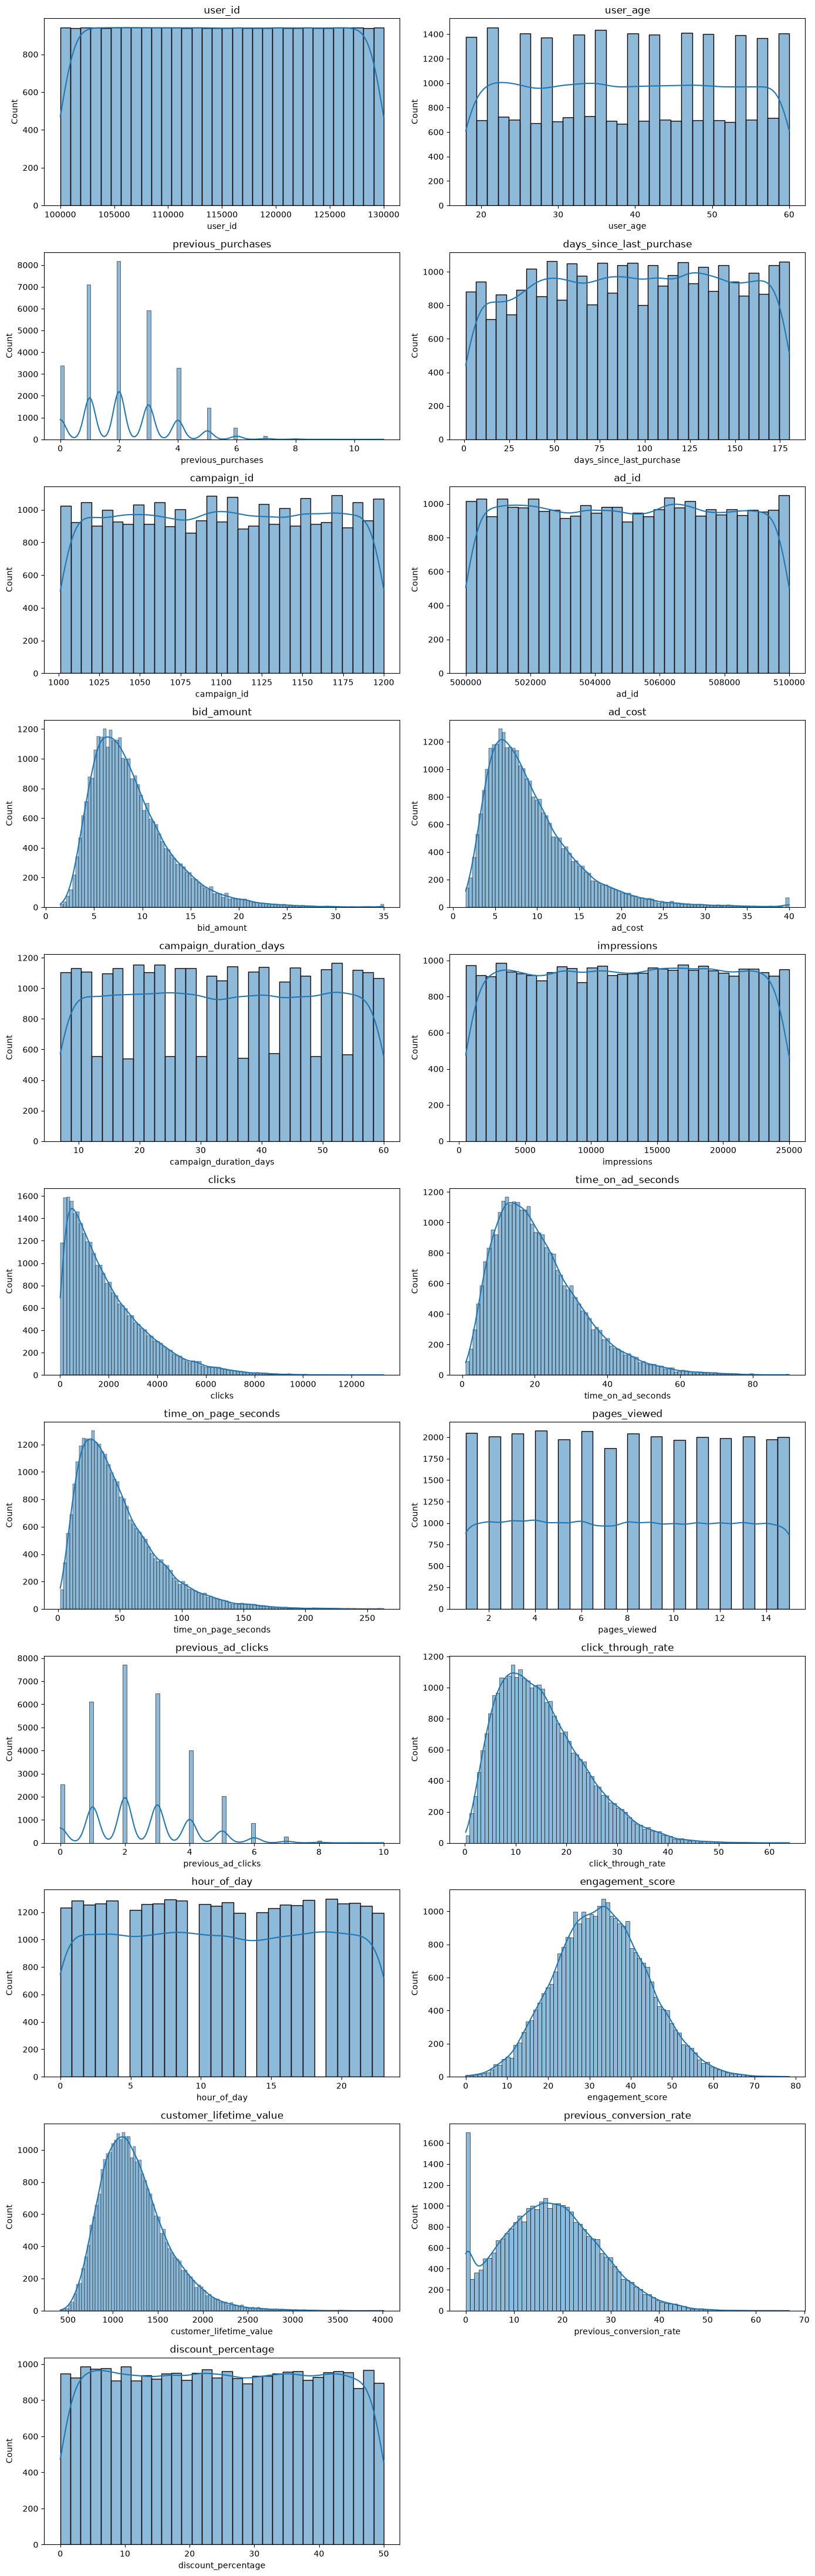

In [11]:
def plot_histograms(df, columns):
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(col)

    # Remove extra empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

numerical_cols = df_ecommerce.select_dtypes(include=["number"]).columns
numerical_cols = numerical_cols.drop("conversion")

plot_histograms(df_ecommerce, numerical_cols)

- user_age, days_since_last_purchase, campaign_duration_days, impressions, pages_viewed, hour_of_day and discount_percentage show fairly spread distributions across their respective ranges.
- bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value show right-skewed distributions.
- engagement_score shows an approximately bell-shaped distribution, with most values concentrated around the center.
- previous_purchases and previous_ad_clicks are discrete features, with values concentrated at specific levels.
- previous_conversion_rate shows a higher concentration at zero with a right-skewed distribution.
- user_id, campaign_id and ad_id show near-uniform distributions and behave like identifier columns, so they can be evaluated for removal during preprocessing.

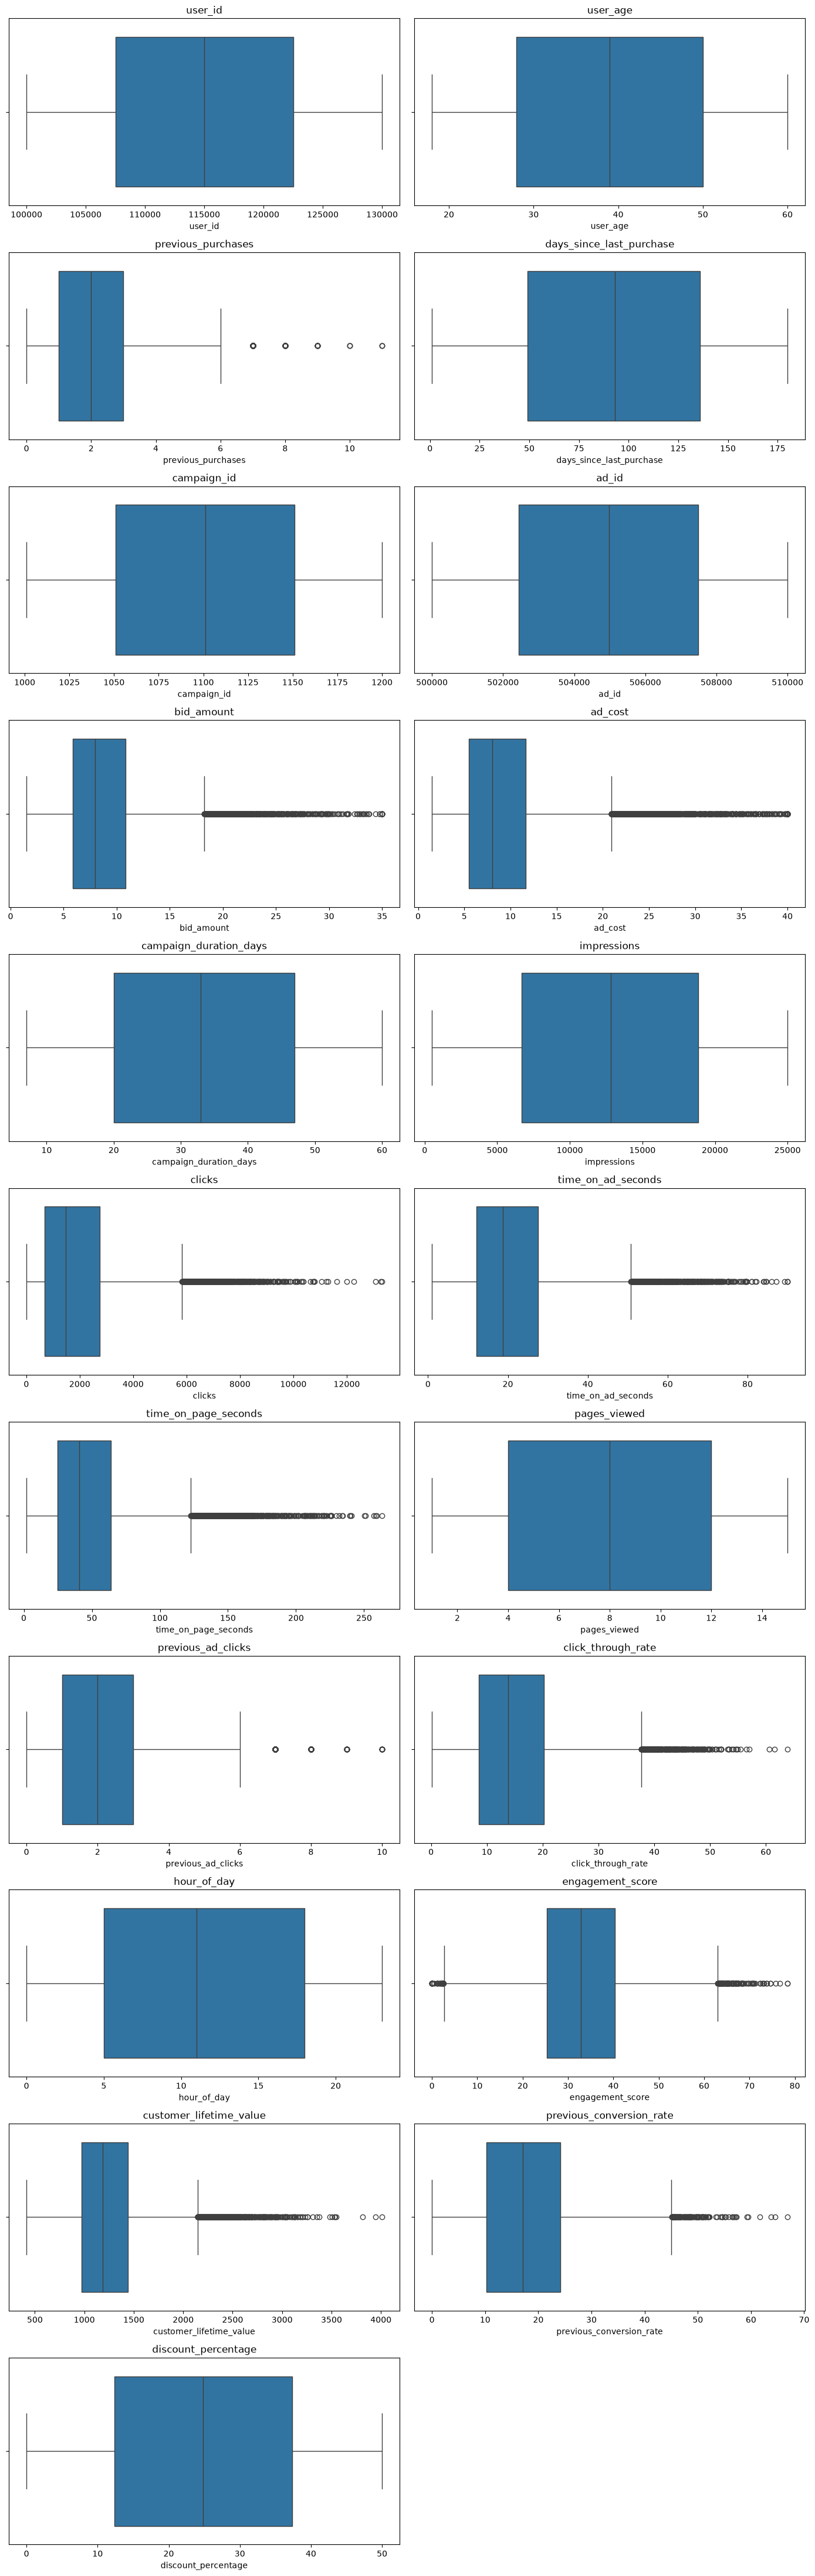

In [12]:
def plot_boxplots(df, columns):
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(col)

    # Remove extra empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_boxplots(df_ecommerce, numerical_cols)

- bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value show a noticeable number of upper-end outliers.
- engagement_score and previous_conversion_rate also show some upper-end outliers.
- previous_purchases and previous_ad_clicks contain a small number of high-value outliers.
- user_age, days_since_last_purchase, campaign_duration_days, impressions, pages_viewed, hour_of_day and discount_percentage show no major outlier concern.
- user_id, campaign_id and ad_id do not show meaningful outliers because they are identifier columns and will be evaluated for removal.

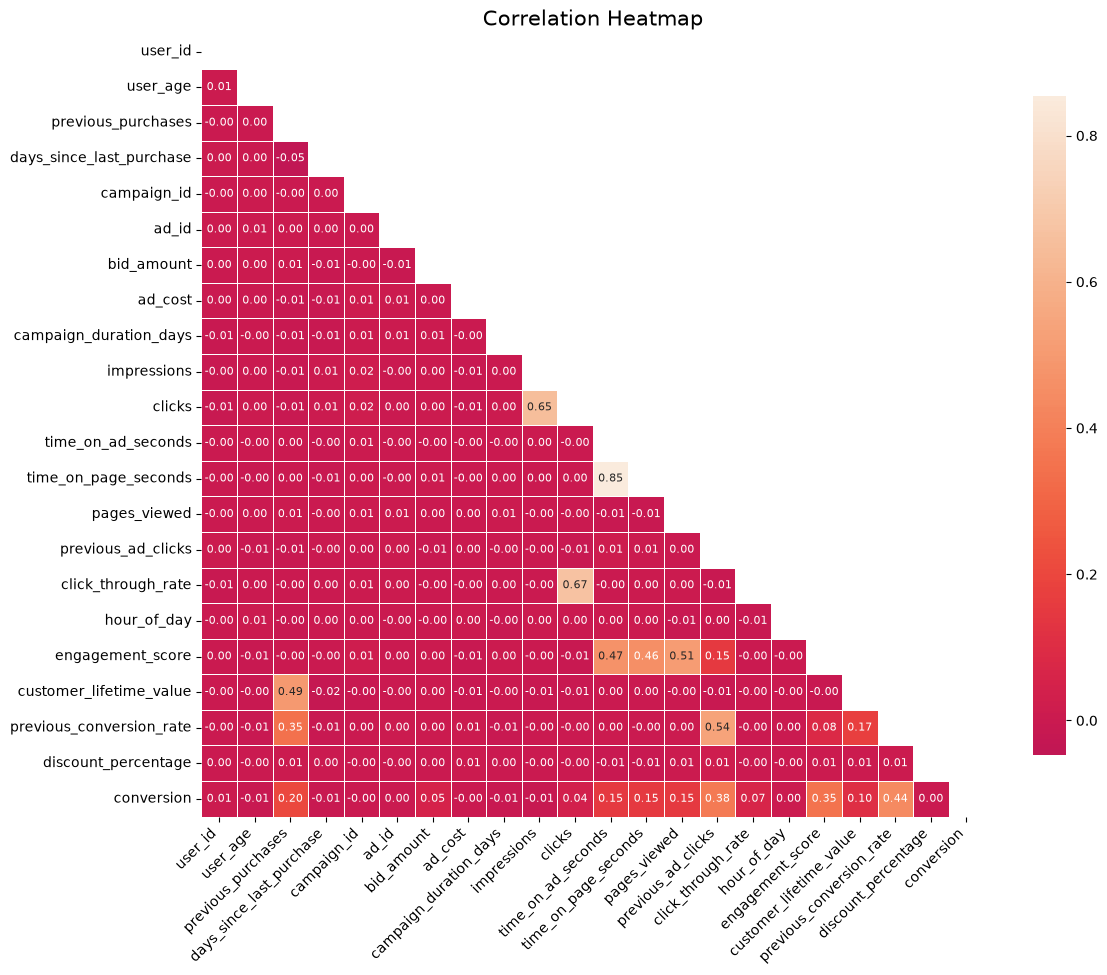

In [14]:
# Correlation Matrix

corr = df_ecommerce.select_dtypes(include=["number"]).corr()

# Hide upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="rocket",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Keep only strong correlations (>=0.30)

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

important_corr = corr_pairs[
    corr_pairs["Correlation"].abs() >= 0.30
].sort_values(by="Correlation", ascending=False)

important_corr

,Feature 1,Feature 2,Correlation
254,time_on_ad_seconds,time_on_page_seconds,0.854261
235,clicks,click_through_rate,0.668966
208,impressions,clicks,0.647163
327,previous_ad_clicks,previous_conversion_rate,0.535512
303,pages_viewed,engagement_score,0.512381
62,previous_purchases,customer_lifetime_value,0.492223
259,time_on_ad_seconds,engagement_score,0.470971
281,time_on_page_seconds,engagement_score,0.458982
439,previous_conversion_rate,conversion,0.438313
329,previous_ad_clicks,conversion,0.376550


- Most numerical features show weak correlation with each other.
- Stronger relationships are observed between time_on_ad_seconds and time_on_page_seconds (0.85), clicks and impressions (0.65), and clicks and click_through_rate (0.67).
- previous_purchases has a moderate positive relationship with customer_lifetime_value (0.49).
- previous_ad_clicks has a moderate positive relationship with previous_conversion_rate (0.54).
- The target conversion shows its higher numerical correlations with previous_conversion_rate (0.44), previous_ad_clicks (0.38), and engagement_score (0.35).
- No feature will be removed based only on correlation; feature usefulness will be evaluated during model building.

### Bivariate analysis

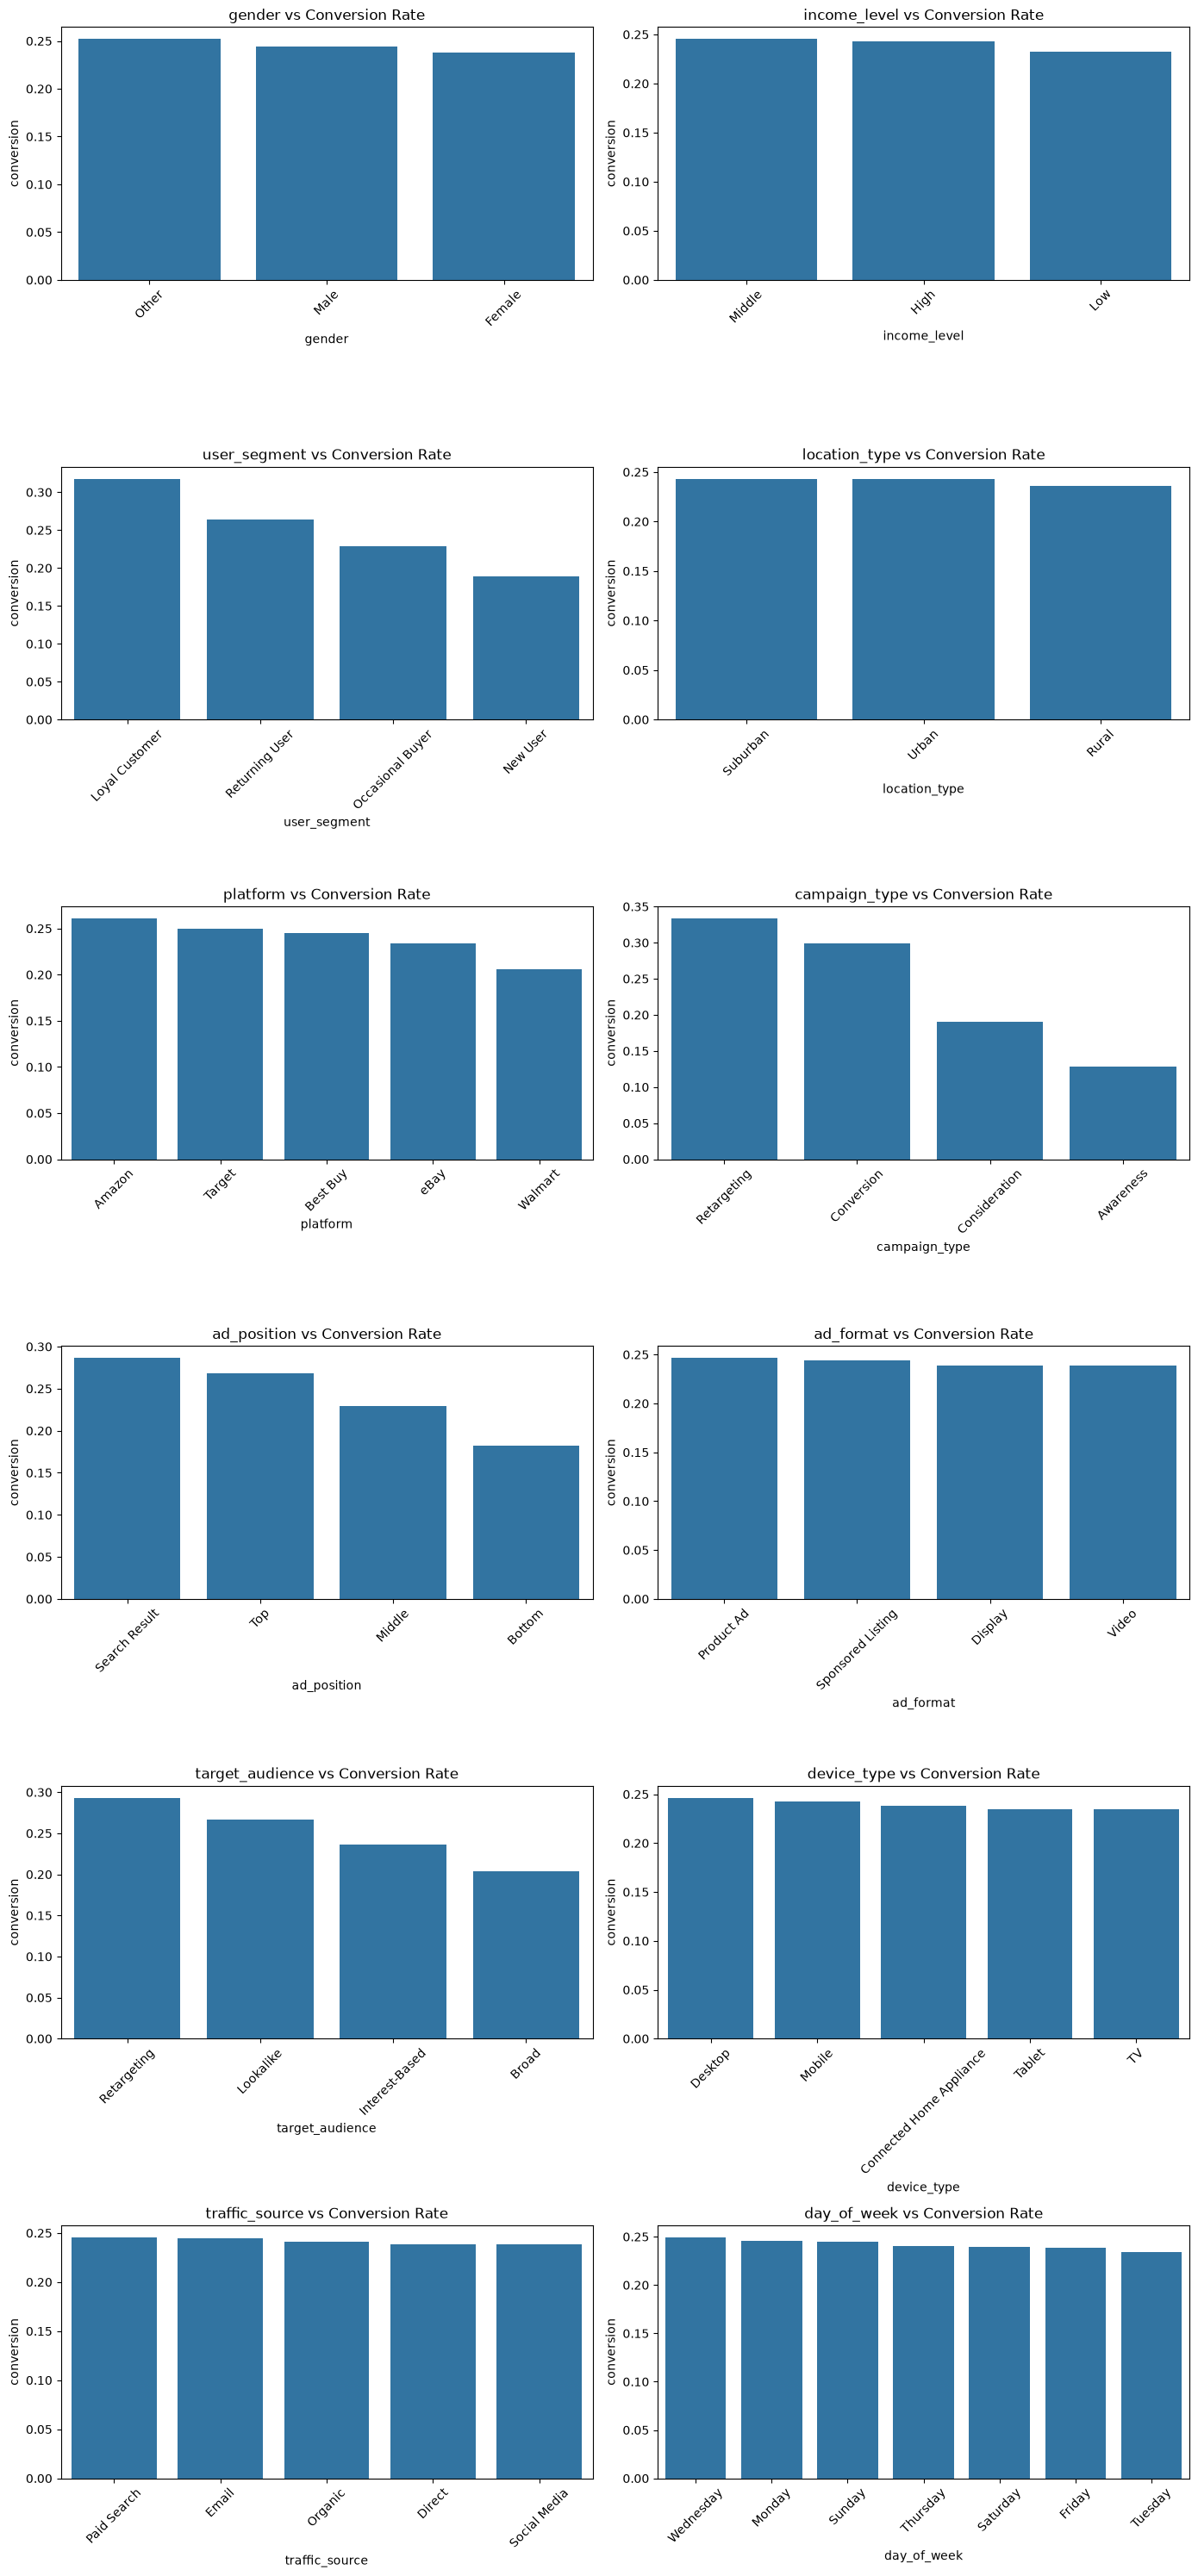

In [16]:
# Categorical Features vs Conversion

def plot_categorical_conversion(df, columns, target="conversion"):
    
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        conversion_rate = (
            df.groupby(col)[target]
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )

        sns.barplot(
            data=conversion_rate,
            x=col,
            y=target,
            ax=axes[i]
        )

        axes[i].set_title(f"{col} vs Conversion Rate")
        axes[i].tick_params(axis="x", rotation=45)

    # Remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


categorical_cols = ["gender","income_level","user_segment","location_type","platform","campaign_type","ad_position",
                    "ad_format","target_audience","device_type","traffic_source","day_of_week"]

plot_categorical_conversion(df_ecommerce, categorical_cols)

- campaign_type, ad_position, target_audience and user_segment show noticeable differences in conversion rates across categories.
- Retargeting has the highest conversion rate among target_audience categories, while Broad has the lowest.
- Retargeting campaign type has the highest conversion rate, while Awareness has the lowest.
- Search Result ad position has a higher conversion rate than Middle and Bottom positions.
- Loyal Customer has the highest conversion rate among user segments, while New User has the lowest.
- Platform, device type, traffic source, day of week, gender, income level, ad format and location type show relatively small differences in conversion rates.

## EDA Summary

- The dataset contains 30,080 records and 34 columns, with a mix of numerical and categorical features.
- A small number of missing values are present in a few numerical features and will be handled during preprocessing.
- The target variable is moderately imbalanced, with approximately 75.8% non-conversion and 24.2% conversion records.
- Numerical features show different distribution patterns, with right-skewness and potential outliers in several advertising, engagement and customer-value features.
- Correlation analysis revealed some strong relationships among numerical features, while the target also shows relationships with features such as previous_conversion_rate, previous_ad_clicks and engagement_score.
- Categorical analysis shows noticeable differences in conversion rates for features such as campaign_type, ad_position, target_audience and user_segment.
- Identifier columns such as user_id, campaign_id and ad_id will be evaluated for removal during preprocessing, while categorical features will be appropriately encoded.

## 4. Data Preprocessing

### 4.1 Data cleaning

In [3]:
# Removing all duplicate rows
df_ecommerce = df_ecommerce.drop_duplicates()

In [4]:
df_ecommerce.duplicated().sum() # verifying that now we dont have any duplicate values 

np.int64(0)

In [5]:
df_ecommerce.shape

(30000, 34)

### Train-Test Split

In [6]:
# Separate features and target
x = df_ecommerce.drop("conversion", axis=1)
y = df_ecommerce["conversion"]

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (24000, 33)
Test: (6000, 33)


- The target variable conversion was separated from the input features before splitting.
- The dataset was split into 80% training (24,080 rows) and 20% testing (6,000 rows).
- Stratified sampling was used to maintain the original conversion/non-conversion ratio in both training and testing datasets.
- The test set will be kept unseen during preprocessing and model training for unbiased final evaluation.

### 4.2 Missing Value Treatment

In [8]:
missing_cols = [
    "ad_cost",
    "campaign_duration_days",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "pages_viewed",
    "hour_of_day",
    "customer_lifetime_value",
    "discount_percentage"
]

for col in missing_cols:
    median_value = x_train[col].median()
    
    x_train[col] = x_train[col].fillna(median_value)
    x_test[col] = x_test[col].fillna(median_value)

In [9]:
x_train.isnull().sum().sum(), x_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

- Missing values in numerical features were imputed using the median.
- The median was calculated from x_train and the same values were applied to x_test to prevent data leakage.
- After imputation, both x_train and x_test contain 0 missing values.

### 4.3 Outlier Handeling

In [10]:
cap_cols = [
    "bid_amount",
    "ad_cost",
    "clicks",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "click_through_rate",
    "customer_lifetime_value"
]
def cap_outliers(x_train, x_test, columns):
    for col in columns:
        Q1 = x_train[col].quantile(0.25)
        Q3 = x_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        x_train[col] = x_train[col].clip(lower=lower, upper=upper)
        x_test[col] = x_test[col].clip(lower=lower, upper=upper)

cap_outliers(x_train, x_test, cap_cols)

- IQR-based capping was applied selectively to features with significant upper-end outliers identified during EDA.
- The treatment was applied to bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value.
- Upper extreme values were capped at the IQR-based upper limits, while all records were retained.
- The treatment reduced the influence of extreme values while preserving the overall data.

#### 4.4 Drop Identifier columns

In [11]:
id_cols = ["user_id", "campaign_id", "ad_id"]

x_train = x_train.drop(columns=id_cols)
x_test = x_test.drop(columns=id_cols)

In [13]:
# Verifying
print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (24000, 30)
Test: (6000, 30)


### Separate categorical and numerical features

In [12]:
cat_cols = x_train.select_dtypes(include="object").columns.tolist()
num_cols = x_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", cat_cols)
print("\nNumerical features:", num_cols)
print("\nTotal features:", len(cat_cols) + len(num_cols))

Categorical features: ['gender', 'income_level', 'user_segment', 'location_type', 'platform', 'campaign_type', 'ad_position', 'ad_format', 'target_audience', 'device_type', 'traffic_source', 'day_of_week']

Numerical features: ['user_age', 'previous_purchases', 'days_since_last_purchase', 'bid_amount', 'ad_cost', 'campaign_duration_days', 'impressions', 'clicks', 'time_on_ad_seconds', 'time_on_page_seconds', 'pages_viewed', 'previous_ad_clicks', 'click_through_rate', 'hour_of_day', 'engagement_score', 'customer_lifetime_value', 'previous_conversion_rate', 'discount_percentage']

Total features: 30


In [15]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Temporary copy for Mutual Information
x_mi = x_train.copy()

# Temporarily encode categorical features
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

x_mi[cat_cols] = encoder.fit_transform(x_mi[cat_cols])

# Identify categorical columns by position
discrete_features = [
    x_mi.columns.get_loc(col)
    for col in cat_cols
]

# Calculate Mutual Information
mi_scores = mutual_info_classif(
    x_mi,
    y_train,
    discrete_features=discrete_features,
    random_state=42
)

# Create ranking
mi_df = pd.DataFrame({
    "Feature": x_train.columns,
    "MI Score": mi_scores
}).sort_values(
    by="MI Score",
    ascending=False
)

mi_df

,Feature,MI Score
28,previous_conversion_rate,0.103554
20,previous_ad_clicks,0.075616
26,engagement_score,0.065952
8,campaign_type,0.018149
5,previous_purchases,0.014834
19,pages_viewed,0.013785
17,time_on_ad_seconds,0.011210
18,time_on_page_seconds,0.005425
3,user_segment,0.005305
21,click_through_rate,0.004711


In [13]:
x_train_xgb = x_train.copy()
x_test_xgb = x_test.copy()

In [14]:
cat_cols = x_train_xgb.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(cat_cols)

Categorical columns:
['gender', 'income_level', 'user_segment', 'location_type', 'platform', 'campaign_type', 'ad_position', 'ad_format', 'target_audience', 'device_type', 'traffic_source', 'day_of_week']


In [15]:
x_train_xgb = pd.get_dummies(
    x_train_xgb,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

x_test_xgb = pd.get_dummies(
    x_test_xgb,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

x_train_xgb, x_test_xgb = x_train_xgb.align(
    x_test_xgb,
    join="left",
    axis=1,
    fill_value=0
)

print("Train shape:", x_train_xgb.shape)
print("Test shape:", x_test_xgb.shape)

Train shape: (24000, 69)
Test shape: (6000, 69)


In [18]:
from xgboost import XGBClassifier

xgb_fs = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42
)

xgb_fs.fit(
    x_train_xgb,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
xgb_importance = pd.DataFrame({
    "Feature": x_train_xgb.columns,
    "Importance": xgb_fs.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
16,previous_conversion_rate,0.161311
14,engagement_score,0.083640
11,previous_ad_clicks,0.074151
32,campaign_type_Conversion,0.072106
33,campaign_type_Retargeting,0.065329
34,ad_position_Middle,0.041057
31,campaign_type_Consideration,0.041053
22,user_segment_New User,0.036712
1,previous_purchases,0.031186
35,ad_position_Search Result,0.026840


In [20]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_fs,
    x_train_xgb,
    y_train,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [21]:
perm_importance = pd.DataFrame({
    "Feature": x_train_xgb.columns,
    "Importance": perm_result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

perm_importance.head(20)

,Feature,Importance
16,previous_conversion_rate,0.179678
14,engagement_score,0.177394
11,previous_ad_clicks,0.081108
33,campaign_type_Retargeting,0.063263
32,campaign_type_Conversion,0.051099
1,previous_purchases,0.029869
35,ad_position_Search Result,0.018594
22,user_segment_New User,0.016920
36,ad_position_Top,0.013139
12,click_through_rate,0.011709


## 5. Model Building

In [16]:
selected_features = [
    "previous_conversion_rate",
    "engagement_score",
    "previous_ad_clicks",
    "campaign_type",
    "previous_purchases",
    "ad_position",
    "user_segment",
    "target_audience",
    "click_through_rate",
    "bid_amount",
    "customer_lifetime_value",
    "pages_viewed",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "platform"
]

In [ ]:
Create reduced datasets

In [17]:
x_train_selected = x_train[selected_features].copy()
x_test_selected = x_test[selected_features].copy()

print("Selected Train Shape:", x_train_selected.shape)
print("Selected Test Shape:", x_test_selected.shape)

Selected Train Shape: (24000, 15)
Selected Test Shape: (6000, 15)


In [ ]:
Verify the selected features

In [18]:
print("Selected Features:")
for i, feature in enumerate(selected_features, 1):
    print(i, feature)

Selected Features:
1 previous_conversion_rate
2 engagement_score
3 previous_ad_clicks
4 campaign_type
5 previous_purchases
6 ad_position
7 user_segment
8 target_audience
9 click_through_rate
10 bid_amount
11 customer_lifetime_value
12 pages_viewed
13 time_on_ad_seconds
14 time_on_page_seconds
15 platform


In [ ]:
Now encode ONLY these 15 features

In [19]:
cat_cols_selected = x_train_selected.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical features:")
print(cat_cols_selected)

Categorical features:
['campaign_type', 'ad_position', 'user_segment', 'target_audience', 'platform']


In [20]:
x_train_selected = pd.get_dummies(
    x_train_selected,
    columns=cat_cols_selected,
    drop_first=False,
    dtype=int
)

x_test_selected = pd.get_dummies(
    x_test_selected,
    columns=cat_cols_selected,
    drop_first=False,
    dtype=int
)

x_train_selected, x_test_selected = x_train_selected.align(
    x_test_selected,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded Train Shape:", x_train_selected.shape)
print("Encoded Test Shape:", x_test_selected.shape)

Encoded Train Shape: (24000, 31)
Encoded Test Shape: (6000, 31)


In [21]:
from xgboost import XGBClassifier

selected_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42
)

selected_xgb.fit(
    x_train_selected,
    y_train
)

print("Selected-feature XGBoost trained successfully.")

Selected-feature XGBoost trained successfully.


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_selected_pred = selected_xgb.predict(x_test_selected)
y_selected_prob = selected_xgb.predict_proba(x_test_selected)[:, 1]

print("SELECTED-FEATURE XGBOOST")
print("=" * 40)
print("Accuracy :", accuracy_score(y_test, y_selected_pred))
print("Precision:", precision_score(y_test, y_selected_pred))
print("Recall   :", recall_score(y_test, y_selected_pred))
print("F1 Score :", f1_score(y_test, y_selected_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_selected_prob))

SELECTED-FEATURE XGBOOST
Accuracy : 0.851
Precision: 0.735494880546075
Recall   : 0.5961272475795297
F1 Score : 0.6585179526355996
ROC-AUC  : 0.9078247141570253


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train predictions
y_train_selected_pred = selected_xgb.predict(x_train_selected)
y_train_selected_prob = selected_xgb.predict_proba(x_train_selected)[:, 1]

# Test predictions
y_test_selected_pred = selected_xgb.predict(x_test_selected)
y_test_selected_prob = selected_xgb.predict_proba(x_test_selected)[:, 1]

print("SELECTED-FEATURE XGBOOST")
print("=" * 50)

print("\nTRAIN PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_selected_pred))
print("Precision:", precision_score(y_train, y_train_selected_pred))
print("Recall   :", recall_score(y_train, y_train_selected_pred))
print("F1 Score :", f1_score(y_train, y_train_selected_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_selected_prob))

print("\nTEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_selected_pred))
print("Precision:", precision_score(y_test, y_test_selected_pred))
print("Recall   :", recall_score(y_test, y_test_selected_pred))
print("F1 Score :", f1_score(y_test, y_test_selected_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_selected_prob))

SELECTED-FEATURE XGBOOST

TRAIN PERFORMANCE
Accuracy : 0.8704166666666666
Precision: 0.7838641188959661
Recall   : 0.6383125864453665
F1 Score : 0.7036401753382886
ROC-AUC  : 0.9244473191230363

TEST PERFORMANCE
Accuracy : 0.851
Precision: 0.735494880546075
Recall   : 0.5961272475795297
F1 Score : 0.6585179526355996
ROC-AUC  : 0.9078247141570253


In [24]:
import pickle

with open("selected_xgb_model.pkl", "wb") as f:
    pickle.dump(selected_xgb, f)

print("Model saved successfully!")

Model saved successfully!


In [25]:
import json

selected_features = [
    "previous_conversion_rate",
    "engagement_score",
    "previous_ad_clicks",
    "campaign_type",
    "previous_purchases",
    "ad_position",
    "user_segment",
    "target_audience",
    "click_through_rate",
    "bid_amount",
    "customer_lifetime_value",
    "pages_viewed",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "platform"
]

categorical_features = [
    "campaign_type",
    "ad_position",
    "user_segment",
    "target_audience",
    "platform"
]

project_data = {
    "selected_features": selected_features,
    "categorical_features": categorical_features,
    "columns": x_train_selected.columns.tolist()
}

json_path = r"C:\Users\vijay\AI & DS\Ecommerce_Ad_Conversion\project_app\project_data.json"

with open(json_path, "w") as f:
    json.dump(project_data, f, indent=4)

print("project_data.json created successfully!")
print("Number of model columns:", len(x_train_selected.columns))

project_data.json created successfully!
Number of model columns: 31


In [26]:
print(df_ecommerce["campaign_type"].unique())

<StringArray>
['Awareness', 'Consideration', 'Conversion', 'Retargeting']
Length: 4, dtype: str


In [27]:
print(df_ecommerce["ad_position"].unique())
print(df_ecommerce["user_segment"].unique())
print(df_ecommerce["target_audience"].unique())
print(df_ecommerce["platform"].unique())

<StringArray>
['Top', 'Middle', 'Search Result', 'Bottom']
Length: 4, dtype: str
<StringArray>
['New User', 'Occasional Buyer', 'Loyal Customer', 'Returning User']
Length: 4, dtype: str
<StringArray>
['Broad', 'Retargeting', 'Interest-Based', 'Lookalike']
Length: 4, dtype: str
<StringArray>
['Target', 'Best Buy', 'Amazon', 'eBay', 'Walmart']
Length: 5, dtype: str


In [28]:
print(x_train_selected.columns.tolist())

['previous_conversion_rate', 'engagement_score', 'previous_ad_clicks', 'previous_purchases', 'click_through_rate', 'bid_amount', 'customer_lifetime_value', 'pages_viewed', 'time_on_ad_seconds', 'time_on_page_seconds', 'campaign_type_Awareness', 'campaign_type_Consideration', 'campaign_type_Conversion', 'campaign_type_Retargeting', 'ad_position_Bottom', 'ad_position_Middle', 'ad_position_Search Result', 'ad_position_Top', 'user_segment_Loyal Customer', 'user_segment_New User', 'user_segment_Occasional Buyer', 'user_segment_Returning User', 'target_audience_Broad', 'target_audience_Interest-Based', 'target_audience_Lookalike', 'target_audience_Retargeting', 'platform_Amazon', 'platform_Best Buy', 'platform_Target', 'platform_Walmart', 'platform_eBay']


# 8. Final Model Comparison

- All evaluated models and model improvement experiments are compared based on their train and test performance.
- The comparison includes **Accuracy, Precision, Recall, F1-score and ROC-AUC** wherever available.
- Both training and testing performance are considered to identify overfitting and generalization.
- Additional experiments such as feature selection, threshold optimization, class weighting and stacking are also included.
- The comparison helps identify the most suitable model for the final prediction system based on **performance, precision and generalization**.
- The final model is selected after considering the overall results and the project's business requirements.

In [3]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost",
        "Feature Selected XGBoost",
        "Threshold Optimized XGBoost",
        "Youden's J XGBoost",
        "Class Weighted XGBoost",
        "Stacking"
    ],

    "Train Accuracy": [
        0.7450, 1.0000, 0.9998, 0.9440, 0.8806, 0.8693,
        None, None, None, None, None
    ],
    "Test Accuracy": [
        0.7422, 0.7647, 0.8268, 0.8215, 0.8233, 0.8522,
        None, None, None, None, 0.8480
    ],

    "Train Precision": [
        0.4820, None, 0.9993, 0.8168, 0.6899, 0.7877,
        None, None, 0.6505, None, None
    ],
    "Test Precision": [
        0.4783, 0.5120, 0.6500, 0.6097, 0.6005, 0.7458,
        0.7029, 0.6025, 0.5737, 0.6245, 0.7338
    ],

    "Train Recall": [
        0.7740, None, 1.0000, 0.9895, 0.9168, 0.6267,
        None, None, 0.9395, None, None
    ],
    "Test Recall": [
        0.7690, 0.5160, 0.6100, 0.7206, 0.7974, 0.5864,
        0.5858, 0.7399, 0.8313, 0.7144, 0.5795
    ],

    "Train F1": [
        0.5940, None, 0.9997, 0.8948, 0.7873, 0.6981,
        0.8791, None, 0.7687, 0.9231, 0.6683
    ],
    "Test F1": [
        0.5898, 0.5138, 0.6293, 0.6605, 0.6851, 0.6566,
        0.6390, 0.6642, 0.6789, 0.6665, 0.6476
    ],

    "Train ROC-AUC": [
        0.8384, None, 1.0000, 0.9950, 0.9625, 0.9246,
        None, None, None, None, None
    ],
    "Test ROC-AUC": [
        0.8367, 0.6798, 0.8807, 0.8849, 0.9028, 0.9072,
        0.8914, 0.8907, None, 0.8928, 0.9026
    ]
})

final_comparison

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.7450,0.7422,0.4820,0.4783,0.7740,0.7690,0.5940,0.5898,0.8384,0.8367
1,Decision Tree,1.0000,0.7647,NaN,0.5120,NaN,0.5160,NaN,0.5138,NaN,0.6798
2,Random Forest,0.9998,0.8268,0.9993,0.6500,1.0000,0.6100,0.9997,0.6293,1.0000,0.8807
3,Tuned Random Forest,0.9440,0.8215,0.8168,0.6097,0.9895,0.7206,0.8948,0.6605,0.9950,0.8849
4,XGBoost,0.8806,0.8233,0.6899,0.6005,0.9168,0.7974,0.7873,0.6851,0.9625,0.9028
5,Tuned XGBoost,0.8693,0.8522,0.7877,0.7458,0.6267,0.5864,0.6981,0.6566,0.9246,0.9072
6,Feature Selected XGBoost,NaN,NaN,NaN,0.7029,NaN,0.5858,0.8791,0.6390,NaN,0.8914
7,Threshold Optimized XGBoost,NaN,NaN,NaN,0.6025,NaN,0.7399,NaN,0.6642,NaN,0.8907
8,Youden's J XGBoost,NaN,NaN,0.6505,0.5737,0.9395,0.8313,0.7687,0.6789,NaN,NaN
9,Class Weighted XGBoost,NaN,NaN,NaN,0.6245,NaN,0.7144,0.9231,0.6665,NaN,0.8928


# 9. Final Model Selection

- After comparing all baseline models and additional improvement experiments, **Hyperparameter-Tuned XGBoost** was selected as the final classification model.
- It achieved a test **Precision of 0.7458**, which was the highest among the evaluated models and is important for reliable conversion predictions.
- It achieved a test **ROC-AUC of 0.9072**, indicating strong ability to distinguish between converters and non-converters.
- The train-test F1-score gap was approximately **4.15 percentage points**, indicating relatively good generalization.
- Although some experiments achieved a slightly higher F1-score or recall, they did not provide the same combination of precision, ROC-AUC and generalization.
- Therefore, **Hyperparameter-Tuned XGBoost was selected as the final model**.

In [34]:
final_model = best_xgb

print("Final Model: Hyperparameter-Tuned XGBoost")

Final Model: Hyperparameter-Tuned XGBoost


## 10. Final Model Evaluation

### 10.1 Prediction Probabilities

In [35]:
# Generate prediction probabilities and class predictions
y_test_proba = final_model.predict_proba(x_test)[:, 1]
y_test_pred = final_model.predict(x_test)

print("Predictions generated successfully.")
print("Probability range:", y_test_proba.min(), "to", y_test_proba.max())

Predictions generated successfully.
Probability range: 0.00012877483 to 0.9974426


### 10.2 Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4265  289]
 [ 598  848]]


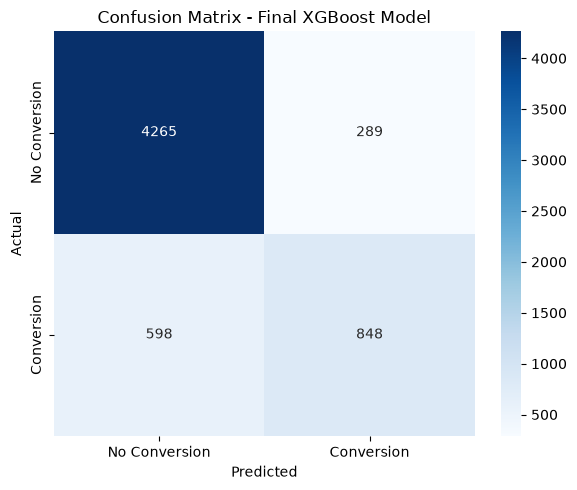

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Conversion", "Conversion"],
    yticklabels=["No Conversion", "Conversion"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final XGBoost Model")
plt.tight_layout()
plt.show()

### 10.3 ROC Curve

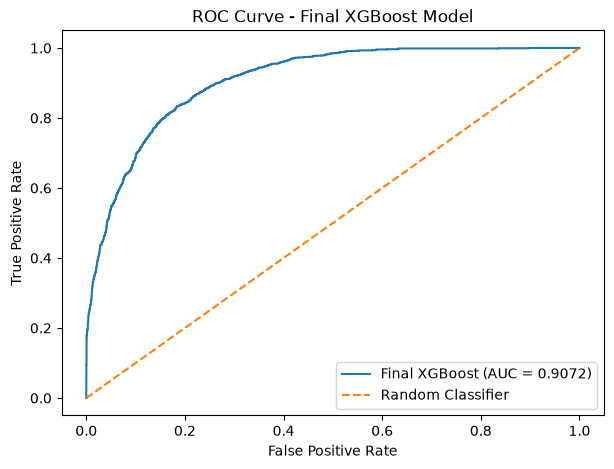

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Final XGBoost (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.show()

### 10.4 Precision-Recall Curve

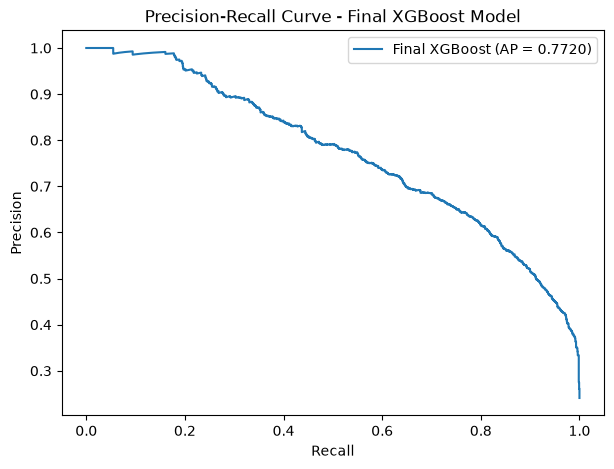

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

ap_score = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Final XGBoost (AP = {ap_score:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.legend()
plt.show()

### 10.5 Classification Report

In [40]:
from sklearn.metrics import classification_report

print("Classification Report - Final XGBoost Model")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Conversion", "Conversion"]
    )
)

Classification Report - Final XGBoost Model
               precision    recall  f1-score   support

No Conversion       0.88      0.94      0.91      4554
   Conversion       0.75      0.59      0.66      1446

     accuracy                           0.85      6000
    macro avg       0.81      0.76      0.78      6000
 weighted avg       0.85      0.85      0.85      6000



## Final Model Evaluation Summary

- The final **Hyperparameter-Tuned XGBoost** model achieved a test accuracy of **85.22%**.
- It achieved a **conversion precision of 74.58%**, meaning that most users predicted as converters were actual converters.
- It achieved a **conversion recall of 58.64%** and a **conversion F1-score of 65.66%**.
- The **ROC-AUC of 0.9072** indicates strong discrimination between conversion and non-conversion cases.
- The model provides a good balance of precision, ROC-AUC and generalization, making it suitable for identifying users with higher conversion potential.

# 11. Feature Importance Analysis

- XGBoost feature importance is used to identify the features that contribute most to the model's predictions.
- The features are ranked based on their importance scores.
- The **top 15 features** are visualized to understand the most influential factors in advertisement conversion.
- This analysis helps interpret the model and understand important factors associated with conversion.

In [41]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,previous_conversion_rate,0.160256
15,engagement_score,0.083594
12,previous_ad_clicks,0.075891
31,campaign_type_Conversion,0.074122
32,campaign_type_Retargeting,0.066027
21,user_segment_New User,0.037589
30,campaign_type_Consideration,0.037272
33,ad_position_Middle,0.036623
2,previous_purchases,0.031436
34,ad_position_Search Result,0.028941


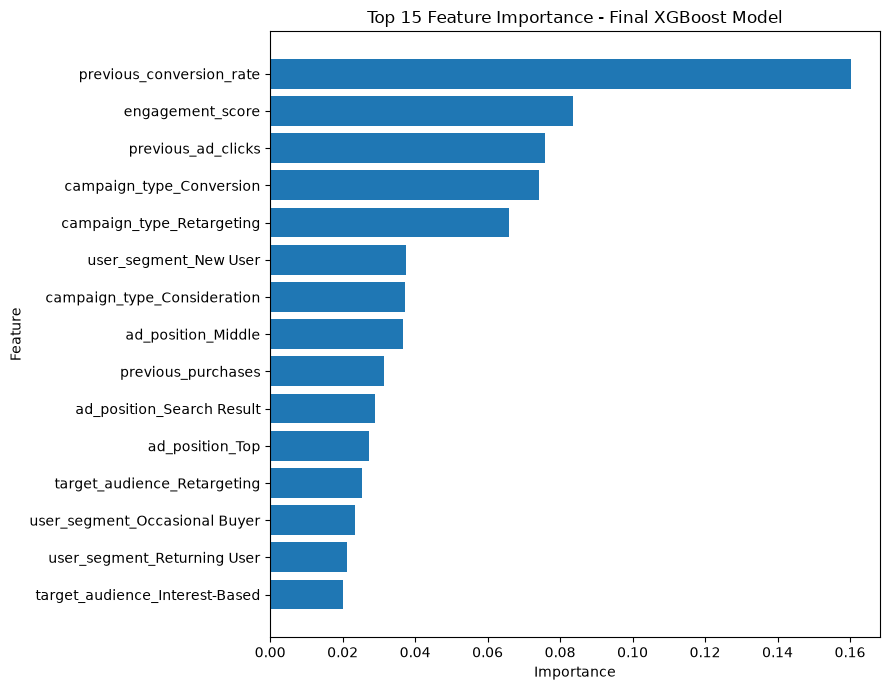

In [42]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Final XGBoost Model")
plt.tight_layout()
plt.show()

# 12. Business Decision Support

- The final model generates a conversion probability for each advertisement interaction.
- These probabilities can help advertisers identify high-potential and low-potential opportunities.
- Businesses can use the predictions to prioritize advertising efforts and improve campaign decisions.
- Conversion probabilities can be grouped into different potential categories for easier business interpretation.

### 12.1 Conversion Probability

In [43]:
prediction_results = pd.DataFrame({
    "Actual Conversion": y_test.values,
    "Predicted Conversion": y_test_pred,
    "Conversion Probability": y_test_proba
})

prediction_results.head(10)

,Actual Conversion,Predicted Conversion,Conversion Probability
0,0,0,0.024086
1,1,1,0.634543
2,1,1,0.577956
3,0,0,0.077721
4,0,0,0.027081
5,0,0,0.003255
6,0,0,0.034638
7,0,0,0.011166
8,0,0,0.317511
9,0,0,0.002378


### 12.2 Conversion Potential Categories

In [44]:
prediction_results["Conversion Category"] = pd.cut(
    prediction_results["Conversion Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Potential", "Medium Potential", "High Potential"],
    include_lowest=True
)

prediction_results.head(10)

,Actual Conversion,Predicted Conversion,Conversion Probability,Conversion Category
0,0,0,0.024086,Low Potential
1,1,1,0.634543,High Potential
2,1,1,0.577956,Medium Potential
3,0,0,0.077721,Low Potential
4,0,0,0.027081,Low Potential
5,0,0,0.003255,Low Potential
6,0,0,0.034638,Low Potential
7,0,0,0.011166,Low Potential
8,0,0,0.317511,Medium Potential
9,0,0,0.002378,Low Potential


### 12.3 Business Interpretation

- The model assigns each advertisement interaction a conversion probability.
- Low-potential interactions can be reviewed for campaign optimization.
- Medium-potential interactions can be considered for further analysis or testing.
- High-potential interactions can be prioritized for advertising attention and targeted campaigns.

# 13. Conclusion

- A machine learning-based classification system was developed to predict whether a sponsored advertisement interaction will result in a purchase.
- The final Hyperparameter-Tuned XGBoost model achieved a test accuracy of **85.22%**, conversion precision of **74.58%**, conversion recall of **58.64%**, and conversion F1-score of **65.66%**.
- The model achieved a **ROC-AUC of 0.9072**, indicating strong discrimination between conversion and non-conversion cases.
- The model generates conversion probabilities that can help businesses identify high-, medium-, and low-potential advertising opportunities.
- These insights can support campaign optimization, prioritization of higher-conversion opportunities, and more informed advertising decisions.

In [46]:
import joblib

joblib.dump(
    final_model,
    r"C:\Users\vijay\AI & DS\Project_1\final_xgboost_conversion_model.pkl"
)

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.
